In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [48]:
data = pd.read_csv(r"C:\Users\RONIT\Desktop\Machine Learning\Python_libraries\scikit_learn\Advertisinggg.csv")

In [49]:
data

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [50]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [51]:
data.tail(5)

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [53]:
data.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [54]:
data.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [55]:
data.shape

(200, 5)

In [56]:
data.drop(data.columns[[0]],axis=1,inplace=True)

In [57]:
data.info

<bound method DataFrame.info of         TV  radio  newspaper  sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]>

In [58]:
data.corr

<bound method DataFrame.corr of         TV  radio  newspaper  sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]>

In [59]:
data.TV.corr(data.sales)

np.float64(0.7822244248616066)

<Axes: >

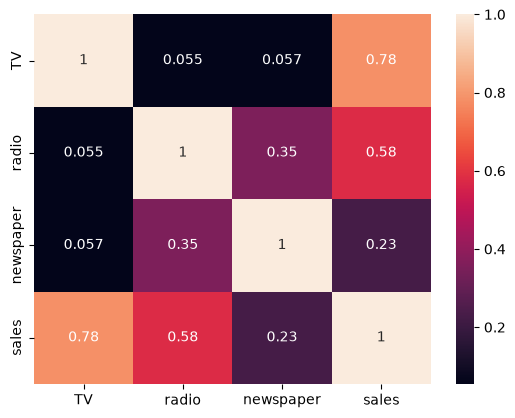

In [60]:
sns.heatmap(data.corr(),annot=True)

In [61]:
from sklearn.linear_model import LinearRegression

# creating x(feature) and y(target)
feature_cols = ['TV','radio','newspaper']
x= data[feature_cols]
y=data.sales

# instantiate and fit
lm1=LinearRegression() # model lm1 refer to first model here
lm1.fit(x,y)

# print the coefficients(intercept and slope)
print(lm1.intercept_)
print(lm1.coef_)


2.938889369459412
[ 0.04576465  0.18853002 -0.00103749]


In [62]:
list(zip(feature_cols,lm1.coef_))

[('TV', np.float64(0.0457646454553976)),
 ('radio', np.float64(0.18853001691820445)),
 ('newspaper', np.float64(-0.0010374930424763285))]

In [63]:
lm1_preds=lm1.predict(x[['TV','radio','newspaper']])

In [65]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

print("R2 score:",r2_score(y,lm1_preds))
print("Mean absolute error:",mean_absolute_error(y,lm1_preds))
print("Mean squared error:",mean_squared_error(y,lm1_preds))

R2 score: 0.8972106381789522
Mean absolute error: 1.2520112296870685
Mean squared error: 2.784126314510936
